## NLP sentiment analysis

Sentiment analysis is the use of computers to interpret the underlying subjective tone of a piece of text and categorize it into positive, neutral, or negative classes.

For this project, sentiment analysis is useful because customer reviews often contain a lot of information about product quality, texture, skin compatibility, packaging, and overall satisfaction. I want to understand whether people feel positively or negatively about a product, and whether the sentiment is linked to specific product attributes or repeated complaints.

My goal is to turn raw review text into useful business insight. Instead of looking at each review individually, I will try to summarize the overall tone of customer feedback, identify which products generate the strongest reactions, and highlight recurring reasons behind positive or negative sentiment. This will help me understand customer experience more clearly and support better product recommendations and analysis.


Using selected columns from reviews dataframe, I can start with sentiment analysis.

### Additional Insights to Explore

    ### Product & Brand Level
    - **Top/bottom rated products and brands** — aggregate sentiment scores by `product_name`/`brand` to find consistent winners and losers
    - **Sentiment vs. star rating mismatch** — reviews where text sentiment disagrees with the numeric rating (e.g., positive text but 1-star rating) — often reveals sarcasm, mislabeled ratings, or shipping/packaging complaints
    unrelated to the product itself
    - **Category-level trends** — compare sentiment across categories (skincare vs. makeup vs. haircare) to see which categories have happier customers

    ### Aspect-Based Sentiment Analysis
    - **Extract specific product attributes** mentioned in reviews (texture, scent, packaging, price, longevity, shade range) and compute sentiment per aspect
    - **"Value for money" sentiment** — isolate mentions of price/cost and see if sentiment skews negative even when overall sentiment is positive

    ### Customer Behavior / Demographics (if available)
    - **Skin type / skin tone correlation** — do reviews from certain skin types or tones trend more negative for specific products (useful for shade-matching or formulation issues)?
    - **Verified purchase vs. non-verified sentiment** — do verified purchasers rate more critically/honestly?
    - **Review recency trends** — has sentiment for a product changed over time (e.g., after a reformulation or price change)?


## Imports and data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [2]:
reviews = pd.read_csv('reviews.csv', )
reviews.head()

,author_id,rating,helpfulness,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,Doesn't apply,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,NaN,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,Doesn't apply,Doesn't apply,Doesn't apply,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,NaN,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,6083038851,5,NaN,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,Doesn't apply,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,47056667835,5,NaN,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [3]:
reviews.shape

(1503850, 15)

In [4]:
data = reviews[['author_id','rating', 'review_text', 'review_title', 'product_name']]
data.head()

,author_id,rating,review_text,review_title,product_name
0,1741593524,5,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,Gentle Hydra-Gel Face Cleanser
1,31423088263,1,I bought this lip mask after reading the revie...,Disappointed,Lip Sleeping Mask Intense Hydration with Vitam...
2,5061282401,5,My review title says it all! I get so excited ...,New Favorite Routine,Lip Sleeping Mask Intense Hydration with Vitam...
3,6083038851,5,I’ve always loved this formula for a long time...,Can't go wrong with any of them,Lip Sleeping Mask Intense Hydration with Vitam...
4,47056667835,5,"If you have dry cracked lips, this is a must h...",A must have !!!,Lip Sleeping Mask Intense Hydration with Vitam...


In [5]:
data.dtypes

author_id       object
rating          object
review_text     object
review_title    object
product_name    object
dtype: object

## Text preprocessing

### Sentence and word tokenization

In [10]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
nltk.download('punkt_tab')

data['review_sentences'] = data['review_text'].apply(
    lambda text: nltk.sent_tokenize(text) if isinstance(text, str) else []
)
data[['review_text', 'review_sentences']].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/gabrielaslomiany/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review_text,review_sentences
0,I use this with the Nudestix “Citrus Clean Bal...,[I use this with the Nudestix “Citrus Clean Ba...
1,I bought this lip mask after reading the revie...,[I bought this lip mask after reading the revi...
2,My review title says it all! I get so excited ...,"[My review title says it all!, I get so excite..."
3,I’ve always loved this formula for a long time...,[I’ve always loved this formula for a long tim...
4,"If you have dry cracked lips, this is a must h...","[If you have dry cracked lips, this is a must ..."


In [11]:
data['review_sentences'][0]

['I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better).',
 'The make-up melt is oil based and removes all of your makeup super easily.',
 'I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up.',
 'It leaves the skin gently cleansed, but without stripping the skin.',
 '10/10 recommend combining with the make-up melt.',
 'It’s perfection!']

In [12]:
data['review_words'] = data['review_text'].apply(
    lambda text: nltk.word_tokenize(text) if isinstance(text, str) else []
)

data['review_words'][0]

['I',
 'use',
 'this',
 'with',
 'the',
 'Nudestix',
 '“',
 'Citrus',
 'Clean',
 'Balm',
 '&',
 'Make-Up',
 'Melt',
 '“',
 'to',
 'double',
 'cleanse',
 'and',
 'it',
 'has',
 'completely',
 'changed',
 'my',
 'skin',
 '(',
 'for',
 'the',
 'better',
 ')',
 '.',
 'The',
 'make-up',
 'melt',
 'is',
 'oil',
 'based',
 'and',
 'removes',
 'all',
 'of',
 'your',
 'makeup',
 'super',
 'easily',
 '.',
 'I',
 'follow-up',
 'with',
 'this',
 'water',
 'based',
 'cleanser',
 ',',
 'and',
 'I',
 'also',
 'use',
 'this',
 'just',
 'by',
 'itself',
 'when',
 'I',
 '’',
 'm',
 'not',
 'wearing',
 'make-up',
 '.',
 'It',
 'leaves',
 'the',
 'skin',
 'gently',
 'cleansed',
 ',',
 'but',
 'without',
 'stripping',
 'the',
 'skin',
 '.',
 '10/10',
 'recommend',
 'combining',
 'with',
 'the',
 'make-up',
 'melt',
 '.',
 'It',
 '’',
 's',
 'perfection',
 '!']

### Accessing and removing stopwords

In [14]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gabrielaslomiany/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# review_words already holds tokenized words per review, so filter each list
data['review_words'] = data['review_words'].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stop_words]
)

data['review_words'][0]

['use',
 'Nudestix',
 '“',
 'Citrus',
 'Clean',
 'Balm',
 '&',
 'Make-Up',
 'Melt',
 '“',
 'double',
 'cleanse',
 'completely',
 'changed',
 'skin',
 '(',
 'better',
 ')',
 '.',
 'make-up',
 'melt',
 'oil',
 'based',
 'removes',
 'makeup',
 'super',
 'easily',
 '.',
 'follow-up',
 'water',
 'based',
 'cleanser',
 ',',
 'also',
 'use',
 '’',
 'wearing',
 'make-up',
 '.',
 'leaves',
 'skin',
 'gently',
 'cleansed',
 ',',
 'without',
 'stripping',
 'skin',
 '.',
 '10/10',
 'recommend',
 'combining',
 'make-up',
 'melt',
 '.',
 '’',
 'perfection',
 '!']

### Removing punctuation

In [16]:
import string

data['review_words'] = data['review_words'].apply(
    lambda tokens: [word for word in tokens if word.lower() not in string.punctuation]
)

data['review_words'][0]

['use',
 'Nudestix',
 '“',
 'Citrus',
 'Clean',
 'Balm',
 'Make-Up',
 'Melt',
 '“',
 'double',
 'cleanse',
 'completely',
 'changed',
 'skin',
 'better',
 'make-up',
 'melt',
 'oil',
 'based',
 'removes',
 'makeup',
 'super',
 'easily',
 'follow-up',
 'water',
 'based',
 'cleanser',
 'also',
 'use',
 '’',
 'wearing',
 'make-up',
 'leaves',
 'skin',
 'gently',
 'cleansed',
 'without',
 'stripping',
 'skin',
 '10/10',
 'recommend',
 'combining',
 'make-up',
 'melt',
 '’',
 'perfection']

### Lemmatization

In [17]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

data['review_words'] = data['review_words'].apply(
    lambda tokens: [lemmatizer.lemmatize(word.lower()) for word in tokens]
)

data['review_words'][0]

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gabrielaslomiany/nltk_data...


['use',
 'nudestix',
 '“',
 'citrus',
 'clean',
 'balm',
 'make-up',
 'melt',
 '“',
 'double',
 'cleanse',
 'completely',
 'changed',
 'skin',
 'better',
 'make-up',
 'melt',
 'oil',
 'based',
 'remove',
 'makeup',
 'super',
 'easily',
 'follow-up',
 'water',
 'based',
 'cleanser',
 'also',
 'use',
 '’',
 'wearing',
 'make-up',
 'leaf',
 'skin',
 'gently',
 'cleansed',
 'without',
 'stripping',
 'skin',
 '10/10',
 'recommend',
 'combining',
 'make-up',
 'melt',
 '’',
 'perfection']

## BoW

In [18]:
import string

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

data['cleaned_review'] = data['review_text'].apply(
    lambda text: preprocess(text) if isinstance(text, str) else ""
)

data['cleaned_review'][0]

'i use this with the nudestix “ citrus clean balm make-up melt “ to double cleanse and it has completely changed my skin for the better the make-up melt is oil based and removes all of your makeup super easily i follow-up with this water based cleanser and i also use this just by itself when i ’ m not wearing make-up it leaves the skin gently cleansed but without stripping the skin 10/10 recommend combining with the make-up melt it ’ s perfection'

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(data['cleaned_review'])

print(vectorizer.get_feature_names_out())
print(bow_matrix.shape)
print(vectorizer.get_feature_names_out()[:20])

['00' '000' '0000' ... '𝘨𝘦' '𝘪𝘯𝘵𝘦𝘯𝘴𝘪𝘧' '𝘵𝘳𝘢𝘪𝘵𝘦𝘮𝘦𝘯𝘵']
(1503850, 63684)
['00' '000' '0000' '00000001' '0000129831723' '0001' '000x' '000xnow'
 '002' '00am' '00pm' '00s' '00x' '01' '02' '025' '028' '03' '03fl' '04']


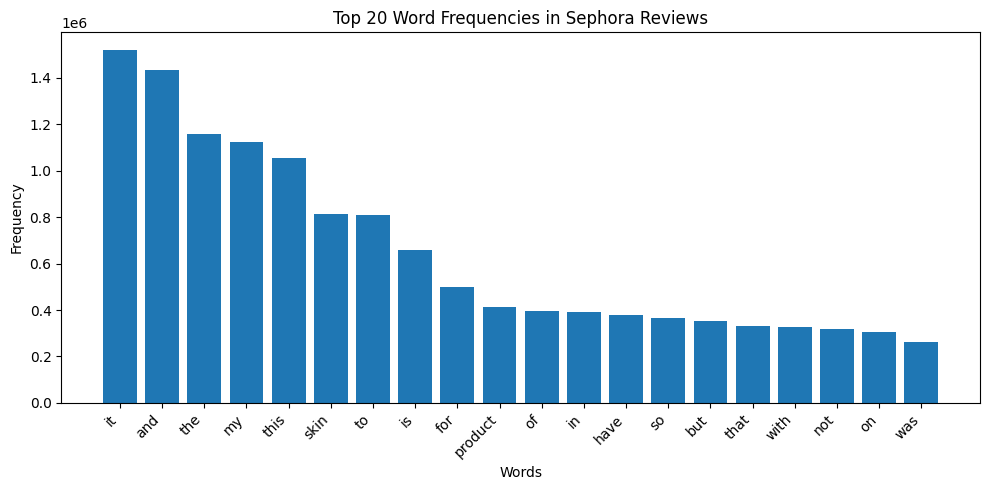

In [20]:
import numpy as np
import matplotlib.pyplot as plt

word_counts = np.asarray(bow_matrix.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

top_n = 20
top_indices = np.argsort(word_counts)[::-1][:top_n]

plt.figure(figsize=(10, 5))
plt.bar(words[top_indices], word_counts[top_indices])
plt.title("Top 20 Word Frequencies in Sephora Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Output of the word frequency seems a bit off considering stop words were dropped?
